In [1]:
from torch_geometric.nn import HGTConv, Linear
from torch_geometric.loader import HGTLoader
from torch_geometric.data import HeteroData
import torch.nn.functional as F
# import pickle5 as pickle
import pickle
import torch.nn as nn
import pandas as pd
from utils import *
import random
import torch
import copy

from tqdm import tqdm

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
node_type1 = 'drug'
node_type2 = 'disease'
rel = 'indication'

In [3]:
config = {
    "num_samples": 512,
    "batch_size": 164,
    "dropout": 0.5,
    "epochs": 300
}

# Load data

In [4]:
primekg_file = '../data/kg.csv'
df = pd.read_csv(primekg_file, sep =",")

/tmp/ipykernel_56381/259066371.py:2: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(primekg_file, sep =",")


In [5]:
# 查看 DataFrame 基本信息（结构）
print("=== DataFrame Info (结构) ===")
print(df.info())

# 查看前 5 行数据（快速预览内容）
print("\n=== First 5 rows (前5行数据) ===")
print(df.head())

# 可选：查看各列的唯一值数量（辅助理解）
print("\n=== Number of unique values per column ===")
print(df.nunique())

=== DataFrame Info (结构) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100498 entries, 0 to 8100497
Data columns (total 12 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   relation          object
 1   display_relation  object
 2   x_index           int64 
 3   x_id              object
 4   x_type            object
 5   x_name            object
 6   x_source          object
 7   y_index           int64 
 8   y_id              object
 9   y_type            object
 10  y_name            object
 11  y_source          object
dtypes: int64(2), object(10)
memory usage: 741.6+ MB
None

=== First 5 rows (前5行数据) ===
          relation display_relation  x_index  x_id        x_type  x_name  \
0  protein_protein              ppi        0  9796  gene/protein  PHYHIP   
1  protein_protein              ppi        1  7918  gene/protein  GPANK1   
2  protein_protein              ppi        2  8233  gene/protein   ZRSR2   
3  protein_protein              ppi        3  4

In [6]:
drug_disease_pairs = df[df['relation']==rel]
drugs, diseases = [], []

for i, row in drug_disease_pairs.iterrows():
    if row['x_type'] == node_type1:
        drugs.append(row['x_index'])
    if row['x_type'] == node_type2:
        diseases.append(row['x_index'])
    
    if row['y_type'] == node_type1:
        drugs.append(row['y_index'])
    if row['y_type'] == node_type2:
        diseases.append(row['y_index'])
        
drugs, diseases = list(set(drugs)), list(set(diseases))

In [7]:
# ========== 插入点：统计 BEFORE ==========
def count_nodes(df):
    nodes_x = df[['x_type', 'x_index']].rename(columns={'x_type': 'type', 'x_index': 'id'})
    nodes_y = df[['y_type', 'y_index']].rename(columns={'y_type': 'type', 'y_index': 'id'})
    all_nodes = pd.concat([nodes_x, nodes_y], ignore_index=True)
    return all_nodes.drop_duplicates().groupby('type').size().to_dict()

# 移除前统计（此时 df 尚未被修改！）
node_counts_before = count_nodes(df)
edge_counts_before = df['relation'].value_counts().to_dict()
# =======================================

In [8]:
to_remove = df[df['x_type']==node_type1]
to_remove = to_remove[~to_remove['x_index'].isin(drugs)]
df.drop(to_remove.index, inplace = True)

In [9]:
to_remove = df[df['y_type']==node_type1]
to_remove = to_remove[~to_remove['y_index'].isin(drugs)]
df.drop(to_remove.index, inplace = True)

In [10]:
to_remove = df[df['x_type']==node_type2]
to_remove = to_remove[~to_remove['x_index'].isin(diseases)]
df.drop(to_remove.index, inplace = True)

In [11]:
to_remove = df[df['y_type']==node_type2]
to_remove = to_remove[~to_remove['y_index'].isin(diseases)]
df.drop(to_remove.index, inplace = True)

In [13]:
# ========== 统计 AFTER 并保存 ==========
node_counts_after = count_nodes(df)
edge_counts_after = df['relation'].value_counts().to_dict()

# ---------- 构建 Table 2: Nodes ----------
all_node_types = sorted(set(node_counts_before.keys()) | set(node_counts_after.keys()))
table2_rows = [
    {
        'Entity': typ,
        'Count before removal': node_counts_before.get(typ, 0),
        'Count after removal': node_counts_after.get(typ, 0),
        'Removal percent': round(
            ((node_counts_before.get(typ, 0) - node_counts_after.get(typ, 0)) 
             / node_counts_before.get(typ, 0) * 100) if node_counts_before.get(typ, 0) > 0 else 0.0,
            2
        )
    }
    for typ in all_node_types
]

# 计算 Total 行（Nodes）
total_before_nodes = sum(row['Count before removal'] for row in table2_rows)
total_after_nodes = sum(row['Count after removal'] for row in table2_rows)
total_percent_nodes = round(
    ((total_before_nodes - total_after_nodes) / total_before_nodes * 100) if total_before_nodes > 0 else 0.0,
    2
)

# 添加 Total 行
table2_rows.append({
    'Entity': 'Total',
    'Count before removal': total_before_nodes,
    'Count after removal': total_after_nodes,
    'Removal percent': total_percent_nodes
})

table2 = pd.DataFrame(table2_rows)

# ---------- 构建 Table 3: Edges ----------
all_relations = sorted(set(edge_counts_before.keys()) | set(edge_counts_after.keys()))
table3_rows = [
    {
        'Entity': rel,
        'Count before removal': edge_counts_before.get(rel, 0),
        'Count after removal': edge_counts_after.get(rel, 0),
        'Removal percent': round(
            ((edge_counts_before.get(rel, 0) - edge_counts_after.get(rel, 0)) 
             / edge_counts_before.get(rel, 0) * 100) if edge_counts_before.get(rel, 0) > 0 else 0.0,
            2
        )
    }
    for rel in all_relations
]

# 计算 Total 行（Edges）
total_before_edges = sum(row['Count before removal'] for row in table3_rows)
total_after_edges = sum(row['Count after removal'] for row in table3_rows)
total_percent_edges = round(
    ((total_before_edges - total_after_edges) / total_before_edges * 100) if total_before_edges > 0 else 0.0,
    2
)

# 添加 Total 行
table3_rows.append({
    'Entity': 'Total',
    'Count before removal': total_before_edges,
    'Count after removal': total_after_edges,
    'Removal percent': total_percent_edges
})

table3 = pd.DataFrame(table3_rows)

# 保存
table2.to_csv('../out/table2_primekg_node_counts.csv', index=False)
table3.to_csv('../out/table3_primekg_edge_counts.csv', index=False)

print(" Tables saved with 'Total' rows!")
# =======================================

✅ Tables saved with 'Total' rows!


In [14]:
new_df = pd.DataFrame()
new_df[0] = df['x_type'] + '::' + df['x_index'].astype(str)
new_df[1] = df['relation']
new_df[2] = df['y_type'] + '::' +df['y_index'].astype(str)

In [15]:
df = new_df
df = df.drop_duplicates()
triplets = df.values.tolist()

In [16]:
entity_dictionary = {}
def insert_entry(entry, ent_type, dic):
    if ent_type not in dic:
        dic[ent_type] = {}
    ent_n_id = len(dic[ent_type])
    if entry not in dic[ent_type]:
         dic[ent_type][entry] = ent_n_id
    return dic

for triple in triplets:
    src = triple[0]
    split_src = src.split('::')
    src_type = split_src[0]
    dest = triple[2]
    split_dest = dest.split('::')
    dest_type = split_dest[0]
    insert_entry(src,src_type,entity_dictionary)
    insert_entry(dest,dest_type,entity_dictionary)

In [17]:
edge_dictionary={}
for triple in triplets:
    src = triple[0]
    split_src = src.split('::')
    src_type = split_src[0]
    dest = triple[2]
    split_dest = dest.split('::')
    dest_type = split_dest[0]
    
    src_int_id = entity_dictionary[src_type][src]
    dest_int_id = entity_dictionary[dest_type][dest]
    
    pair = (src_int_id,dest_int_id)
    etype = (src_type, triple[1],dest_type)
    if etype in edge_dictionary:
        edge_dictionary[etype] += [pair]
    else:
        edge_dictionary[etype] = [pair]

In [18]:
data = HeteroData()

for i, key in enumerate(entity_dictionary.keys()):
    if key != 'drug':
        data[key].x = (torch.ones((len(entity_dictionary[key]), 768)) * i)
    elif key == 'drug':
        data[key].x = (torch.rand((len(entity_dictionary[key]), 767)))
   
    data[key].id = torch.arange(len(entity_dictionary[key]))

for key in edge_dictionary:
    data[key].edge_index = torch.transpose(torch.IntTensor(edge_dictionary[key]), 0, 1).long().contiguous()

# 任务2：度分布与Hub节点分析

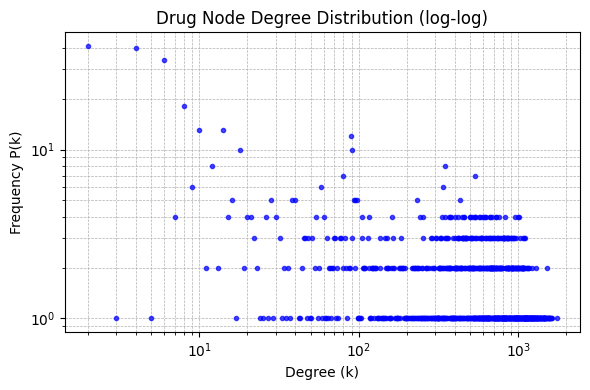

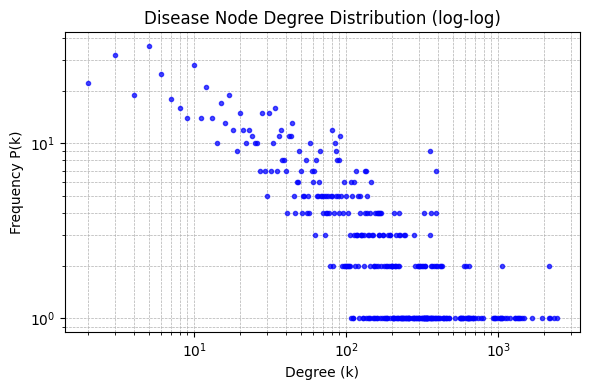

Top 10 Hub Drugs (by total degree):
  drug::14323: degree = 1735
  drug::14999: degree = 1623
  drug::17558: degree = 1598
  drug::14325: degree = 1590
  drug::15087: degree = 1567
  drug::14235: degree = 1566
  drug::15116: degree = 1561
  drug::15001: degree = 1558
  drug::14251: degree = 1555
  drug::14176: degree = 1554

Top 10 Hub Diseases (by total degree):
  disease::32617: degree = 2411
  disease::35771: degree = 2321
  disease::28347: degree = 2184
  disease::36691: degree = 2154
  disease::84243: degree = 2154
  disease::84244: degree = 2153
  disease::28313: degree = 1927
  disease::28849: degree = 1665
  disease::27933: degree = 1481
  disease::30035: degree = 1426


In [20]:
# %% [markdown]
# # 任务2：度分布与Hub节点分析（新增）

# %%
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import os

# 确保输出目录存在
os.makedirs('../out', exist_ok=True)

# 计算药物节点总度（跨所有关系类型）
drug_degrees = torch.zeros(data['drug'].num_nodes)
for etype in data.edge_types:
    if 'drug' in etype:
        edge_index = data[etype].edge_index
        if etype[0] == 'drug':  # drug -> other
            deg = torch.bincount(edge_index[0], minlength=data['drug'].num_nodes)
            drug_degrees += deg
        elif etype[2] == 'drug':  # other -> drug
            deg = torch.bincount(edge_index[1], minlength=data['drug'].num_nodes)
            drug_degrees += deg

# 计算疾病节点总度
disease_degrees = torch.zeros(data['disease'].num_nodes)
for etype in data.edge_types:
    if 'disease' in etype:
        edge_index = data[etype].edge_index
        if etype[0] == 'disease':  # disease -> other
            deg = torch.bincount(edge_index[0], minlength=data['disease'].num_nodes)
            disease_degrees += deg
        elif etype[2] == 'disease':  # other -> disease
            deg = torch.bincount(edge_index[1], minlength=data['disease'].num_nodes)
            disease_degrees += deg

drug_degrees = drug_degrees.numpy()
disease_degrees = disease_degrees.numpy()

# 绘制度分布（log-log）并保存
def plot_degree_distribution(degrees, title, filename):
    degree_counts = Counter(degrees)
    x = np.array(list(degree_counts.keys()))
    y = np.array(list(degree_counts.values()))
    mask = x > 0
    x, y = x[mask], y[mask]
    sorted_idx = np.argsort(x)
    x, y = x[sorted_idx], y[sorted_idx]
    
    plt.figure(figsize=(6, 4))
    plt.loglog(x, y, 'bo', markersize=3, alpha=0.7)
    plt.xlabel('Degree (k)')
    plt.ylabel('Frequency P(k)')
    plt.title(title)
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')  # ✅ 保存高清图
    plt.show()

# 调用绘图并保存
plot_degree_distribution(drug_degrees, "Drug Node Degree Distribution (log-log)", '../out/drug_degree.png')
plot_degree_distribution(disease_degrees, "Disease Node Degree Distribution (log-log)", '../out/disease_degree.png')

# 找出 Top-10 Hub 节点（后续可选保存到文件）
top_drug_idx = np.argsort(drug_degrees)[-10:][::-1]
top_disease_idx = np.argsort(disease_degrees)[-10:][::-1]

print("Top 10 Hub Drugs (by total degree):")
for idx in top_drug_idx:
    drug_name = list(entity_dictionary['drug'].keys())[idx]
    print(f"  {drug_name}: degree = {int(drug_degrees[idx])}")

print("\nTop 10 Hub Diseases (by total degree):")
for idx in top_disease_idx:
    disease_name = list(entity_dictionary['disease'].keys())[idx]
    print(f"  {disease_name}: degree = {int(disease_degrees[idx])}")

Drug log-log correlation ≈ -0.38 (若 < -0.7，支持幂律趋势)


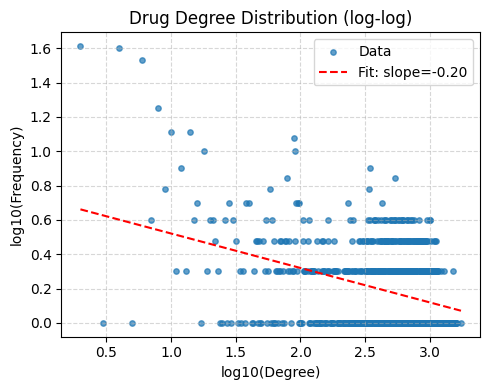

Disease log-log correlation ≈ -0.83 (若 < -0.7，支持幂律趋势)


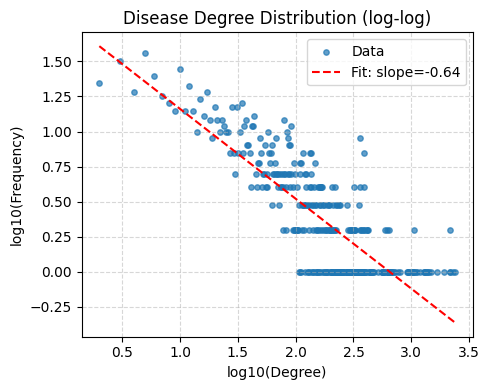

In [22]:
def rough_power_law_check(degrees, name):
    degrees = degrees[degrees > 0]  # 去掉度为0的节点（理论上没有，但安全起见）
    
    from collections import Counter
    degree_count = Counter(degrees)
    
    # 获取唯一的度值 k 和对应的频次 P(k)
    k_vals = np.array(sorted(degree_count.keys()))
    p_vals = np.array([degree_count[k] for k in k_vals])
    
    # 取对数
    log_k = np.log10(k_vals)
    log_p = np.log10(p_vals)
    
    # 计算 log(k) 和 log(P(k)) 的 Pearson 相关系数
    corr = np.corrcoef(log_k, log_p)[0, 1]
    
    print(f"{name} log-log correlation ≈ {corr:.2f} (若 < -0.7，支持幂律趋势)")
    
    # 可选：画出拟合直线辅助判断
    plt.figure(figsize=(5, 4))
    plt.scatter(log_k, log_p, s=15, alpha=0.7, label='Data')
    
    # 线性拟合
    coeffs = np.polyfit(log_k, log_p, 1)
    fit_line = np.polyval(coeffs, log_k)
    plt.plot(log_k, fit_line, 'r--', label=f'Fit: slope={coeffs[0]:.2f}')
    
    plt.xlabel('log10(Degree)')
    plt.ylabel('log10(Frequency)')
    plt.title(f'{name} Degree Distribution (log-log)')
    plt.legend()
    plt.grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'../out/{name.lower()}_loglog_fit.png', dpi=300)
    plt.show()

rough_power_law_check(drug_degrees, "Drug")
rough_power_law_check(disease_degrees, "Disease")

### Add initial embeddings.

In [ ]:
embeddings = pd.read_pickle('../data/entities_embeddings.pkl')
smiles_embeddings = pd.read_pickle('../data/smiles_embeddings.pkl')

for i, row in smiles_embeddings.iterrows():
    if row['id'] in entity_dictionary['drug'].keys():
        drug_id = entity_dictionary['drug'][row['id']]
        data['drug'].x[drug_id] = torch.Tensor(row['embedding'])

for i, row in embeddings.iterrows():
    x_type = row['id'].split('::')[0]
    if x_type in data.node_types and row['id'] in entity_dictionary[x_type] and x_type != 'drug':
        id_ = entity_dictionary[x_type][row['id']]
        data[x_type].x[id_][:768] = torch.Tensor(row['embedding'])

### Load train and validation data of one fold.

In [ ]:
file = open('../data/CV data/train1.pkl', 'rb')
train_data = pickle.load(file)

In [ ]:
file = open('../data/CV data/val1.pkl', 'rb')
val_data = pickle.load(file)

### Creating mask.

In [ ]:
drug_disease_num = train_data[(node_type1, rel, node_type2)]['edge_index'].shape[1]
mask = random.sample(range(drug_disease_num), int(drug_disease_num*0.8))
train_data[(node_type1, rel, node_type2)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type1, rel, node_type2)]['mask'][mask] = True

train_data[(node_type2, rel, node_type1)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type2, rel, node_type1)]['mask'][mask] = True

### Define model.

In [ ]:
class HGT(nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads, num_layers, dropout):
        super().__init__()

        self.lin_dict = nn.ModuleDict()
        for node_type in train_data.node_types:
            self.lin_dict[node_type] = Linear(-1, hidden_channels[0])
            
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            conv = HGTConv(hidden_channels[i], hidden_channels[i+1], train_data.metadata(),
                           num_heads[i])
            self.convs.append(conv)
        
        self.lin = Linear(sum(hidden_channels[1:]), out_channels)
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            node_type: self.dropout(self.lin_dict[node_type](x).relu_())
            for node_type, x in x_dict.items()
        }
        out = {}
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)

            if out=={}:
                out = copy.copy(x_dict)
            else:
                out = {
                    node_type: torch.cat((out[node_type], x_dict[node_type]), dim=1)
                    for node_type, x in x_dict.items()
                }

        return F.relu(self.lin(out[node_type1])), F.relu(self.lin(out[node_type2]))

In [ ]:
class MLPPredictor(nn.Module):
    def __init__(self, channel_num, dropout):
        super().__init__()
        self.L1 = nn.Linear(channel_num * 2, channel_num)
        self.L2 = nn.Linear(channel_num, 1)
        self.bn = nn.BatchNorm1d(num_features=channel_num)
        self.dropout = nn.Dropout(0.2)

    def forward(self, drug_embeddings, disease_embeddings):
        x = torch.cat((drug_embeddings, disease_embeddings), dim=1)
        x = F.relu(self.bn(self.L1(x)))
        x = self.dropout(x)
        x = self.L2(x)
        return x

In [ ]:
def compute_loss(scores, labels):
    pos_weights = torch.clone(labels)
    pos_weights[pos_weights == 1] = ((labels==0).sum() / labels.shape[0])
    pos_weights[pos_weights == 0] = ((labels==1).sum() / labels.shape[0])
    
    return F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weights)
#     return F.binary_cross_entropy_with_logits(scores, labels)

In [ ]:
def define_model(dropout):
    GNN = HGT(hidden_channels=[64, 64, 64, 64],
              out_channels=64,
              num_heads=[8, 8, 8],
              num_layers=3,
              dropout=dropout)

    pred = MLPPredictor(64, dropout)
    model = nn.Sequential(GNN, pred)
    model.to(device)
    
    return GNN, pred, model

In [ ]:
def define_loaders(config):
    kwargs = {'batch_size': config['batch_size'], 'num_workers': 8, 'persistent_workers': True}
    
    train_loader = HGTLoader(train_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    val_loader = HGTLoader(val_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    return train_loader, val_loader

In [ ]:
def edge_exists(edges, edge):
    edges = edges.to(device)
    edge = edge.to(device)
    return (edges == edge).all(dim=0).sum() > 0

### Make batches.

In [ ]:
def make_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    mask = batch[(node_type1, rel, node_type2)]['mask']   
    
    batch_index = (edge_index[0] < batch_size)
    edge_index = edge_index[:, batch_index]
    mask = mask[batch_index]
    edge_label_index = edge_index[:, mask]
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source = random.randint(0, batch_size-1)
        dest = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source], [dest]])
        if edge_exists(edge_index, neg_edge):
            continue
        else:
            neg_edges_source.append(source)
            neg_edges_dest.append(dest)
    
    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)
    edge_index = edge_index[:, ~mask]

    batch[(node_type1, rel, node_type2)]['edge_index'] = edge_index
    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label
    
    batch[(node_type2, rel, node_type1)]['edge_index'] = edge_index
    temp = copy.copy(batch[(node_type2, rel, node_type1)]['edge_index'][0])
    batch[(node_type2, rel, node_type1)]['edge_index'][0] = batch[(node_type2, rel, node_type1)]['edge_index'][1]
    batch[(node_type2, rel, node_type1)]['edge_index'][1] = temp
    
    return batch

In [ ]:
def make_test_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
    edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
    
    source = []
    dest = []
    labels = []
    for i in range(edge_label_index.shape[1]):
        if edge_label_index[0, i] in batch[node_type1]['id'] and edge_label_index[1, i] in batch[node_type2]['id'] \
        and ((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0]) < batch_size:
            if edge_label[i] == 1:
                source.append((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0])
                dest.append((batch[node_type2]['id'] == edge_label_index[1, i]).nonzero(as_tuple=True)[0])

    edge_label_index = torch.zeros(2, len(source)).long()
    edge_label_index[0] = torch.tensor(source)
    edge_label_index[1] = torch.tensor(dest)
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source_node = random.randint(0, batch_size-1)
        dest_node = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source_node], [dest_node]])
        neg_edge_in_orig_graph = torch.Tensor([[batch[node_type1]['id'][source_node]], [batch[node_type2]['id'][dest_node]]])
        if edge_exists(data[(node_type1, rel, node_type2)]['edge_index'], neg_edge_in_orig_graph):
            continue
        else:
            neg_edges_source.append(source_node)
            neg_edges_dest.append(dest_node)

    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)

    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label

    return batch

### Train

In [ ]:
def train(GNN, pred, model, loader, optimizer):
    model.train()
    total_examples = total_loss = 0
    for i, batch in enumerate(iter(loader)):
        optimizer.zero_grad()
        batch = make_batch(batch)
        batch = batch.to(device)
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        if edge_label.shape[0] == 0:
            continue
        
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        out = pred(c, d)[:, 0]
        loss = compute_loss(out, edge_label)
        loss.backward()
        optimizer.step()

        total_examples += edge_label_index.shape[1]
        # total_loss += float(loss) * edge_label_index.shape[1]
        # 方案 B (更常用): 直接使用 .item()，它会自动 detach
        total_loss += loss.item() * edge_label_index.shape[1]

    return total_loss / total_examples

### Test

In [ ]:
@torch.no_grad()
def test(GNN, pred, model, loader):
    model.eval()

    total_examples = total_correct = 0
    out, labels = torch.tensor([]).to(device), torch.tensor([]).to(device)
    source, dest = torch.tensor([]).to(device), torch.tensor([]).to(device)
    for batch in iter(loader):
        batch = make_test_batch(batch)
        batch = batch.to(device)
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        
        if edge_label.shape[0] == 0:
            continue
                
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        batch_out = pred(c, d)[:, 0]
        labels = torch.cat((labels, edge_label))
        out = torch.cat((out, batch_out))
        
        drugs = batch[node_type1]['id'][edge_label_index[0]]
        diseases = batch[node_type2]['id'][edge_label_index[1]]
        source = torch.cat((source, drugs))
        dest = torch.cat((dest, diseases))

    loss = compute_loss(out, labels)    
    return out, labels, source, dest, loss.cpu().numpy()

### Run

In [ ]:
# ... existing imports ...

from tqdm import tqdm

# >>> 新增：元关系权重提取函数 <<<
@torch.no_grad()
def extract_meta_relation_weights(GNN, node_types, edge_types):
    """
    提取 HGT 模型中每层的 meta-relation 先验张量 μ。
    注意：不再依赖 data_loader，而是直接传入 metadata。
    """
    all_weights = {l: {} for l in range(len(GNN.convs))}
    
    # 构建类型到 ID 的映射（与 HGTConv 内部一致）
    node_type_to_id = {nt: i for i, nt in enumerate(node_types)}
    edge_type_to_id = {et: i for i, et in enumerate(edge_types)}
    
    for layer_idx, conv in enumerate(GNN.convs):
        prior = conv.prior  # shape: [num_node_types, num_edge_types, num_node_types]
        if prior is None:
            print(f"Warning: Layer {layer_idx} has no prior tensor (maybe use_prior=False).")
            continue
        for (src, rel, dst) in edge_types:
            if src in node_type_to_id and dst in node_type_to_id and (src, rel, dst) in edge_type_to_id:
                src_id = node_type_to_id[src]
                dst_id = node_type_to_id[dst]
                rel_id = edge_type_to_id[(src, rel, dst)]
                mu_val = prior[src_id, rel_id, dst_id].item()
                all_weights[layer_idx][(src, rel, dst)] = mu_val
    return all_weights
# <<< 结束新增 >>>

In [ ]:
def run(config):
    losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    
    train_loader, val_loader = define_loaders(config)
    GNN, pred, model = define_model(config['dropout'])
    
    optimizer = torch.optim.AdamW(model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 
                                                           T_max=config['epochs'], 
                                                           eta_min=0, 
                                                           last_epoch=-1)
    for epoch in tqdm(range(config['epochs']), desc="Training Progress"):
    # for epoch in range(config['epochs']):
        loss = train(GNN, pred, model, train_loader, optimizer)
        out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
        write_to_out(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, ValLoss: {val_loss:.4f} \n')
        losses.append(loss)
        val_losses.append(val_loss)
        plot_losses(losses, val_losses)

        scheduler.step()
        # 手动打印当前学习率
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch}: Learning Rate = {current_lr}")
        
    torch.save(model.state_dict(), '../out/saved_model.h5')
    
      # >>> 插入分析代码（简洁版）<<<
    GNN.eval()
    node_types, edge_types = train_data.metadata()
    all_weights = extract_meta_relation_weights(GNN, node_types, edge_types)

    # 接下来是 DataFrame 构建、绘图、保存等（和之前一样，但不再包含函数定义）
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    records = []
    for layer, rel_dict in all_weights.items():
        for meta_rel, weight in rel_dict.items():
            records.append({
                'Layer': layer + 1,
                'MetaRelation': f"{meta_rel[0]}-{meta_rel[1]}-{meta_rel[2]}",
                'Weight': weight
            })
    df_weights = pd.DataFrame(records)
    # ...（后续绘图和分析代码保持不变）...
    # >>> 插入结束 <<<

    out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
    AUPR(out, labels)
    AUROC(out, labels)

In [ ]:
run(config)